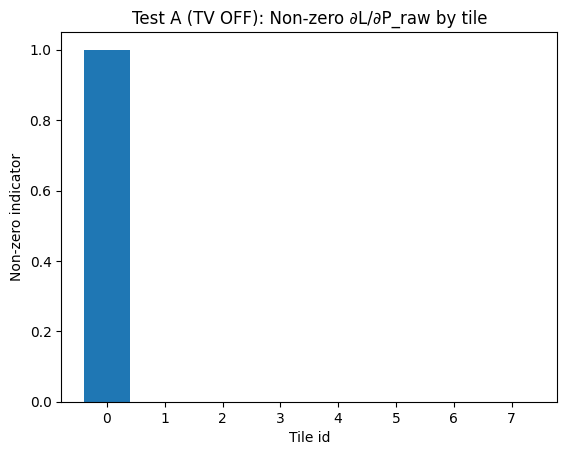

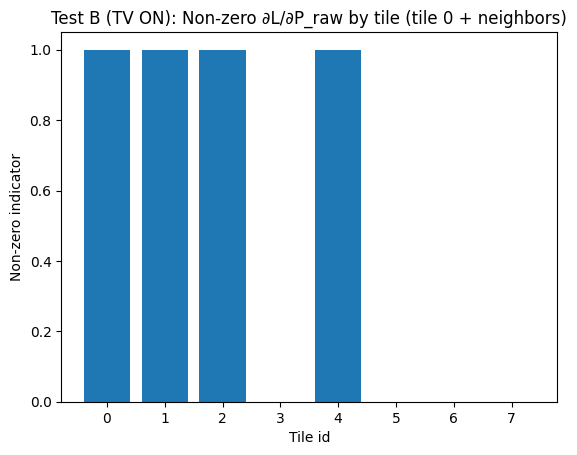

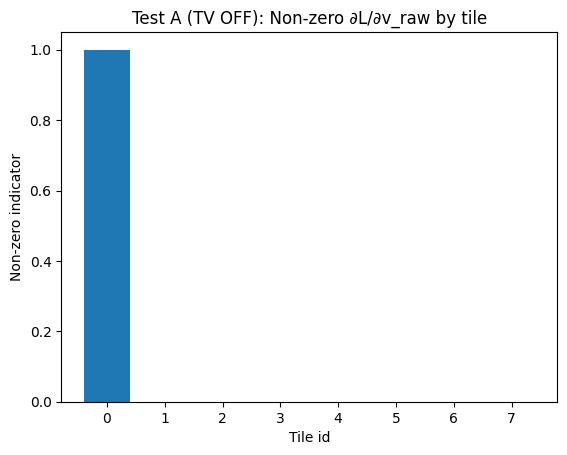

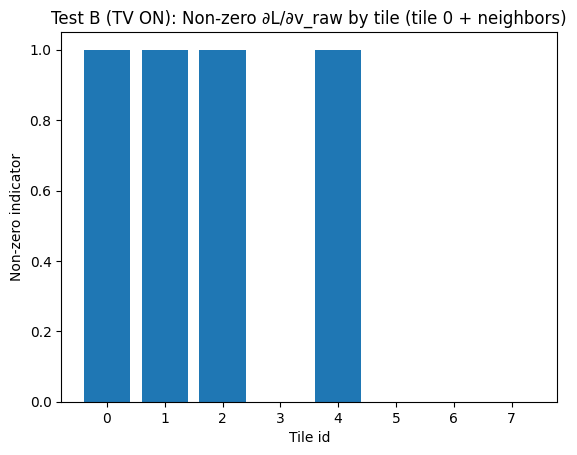

In [1]:
import torch
import matplotlib.pyplot as plt

# Paste these from your run (or re-run the script and print gP/gv and copy here).
# For now, example vectors showing the *support* pattern; replace with real grads if you want magnitudes.
gP_A = torch.tensor([1,0,0,0,0,0,0,0], dtype=torch.float32)   # Test A nonzero only tile 0
gv_A = torch.tensor([1,0,0,0,0,0,0,0], dtype=torch.float32)

gP_B = torch.tensor([1,1,1,0,1,0,0,0], dtype=torch.float32)   # Test B nonzero tiles [0,1,2,4]
gv_B = torch.tensor([1,1,1,0,1,0,0,0], dtype=torch.float32)

tiles = list(range(8))

plt.figure()
plt.bar(tiles, gP_A.numpy())
plt.title("Test A (TV OFF): Non-zero ∂L/∂P_raw by tile")
plt.xlabel("Tile id")
plt.ylabel("Non-zero indicator")
plt.xticks(tiles)
plt.show()

plt.figure()
plt.bar(tiles, gP_B.numpy())
plt.title("Test B (TV ON): Non-zero ∂L/∂P_raw by tile (tile 0 + neighbors)")
plt.xlabel("Tile id")
plt.ylabel("Non-zero indicator")
plt.xticks(tiles)
plt.show()

plt.figure()
plt.bar(tiles, gv_A.numpy())
plt.title("Test A (TV OFF): Non-zero ∂L/∂v_raw by tile")
plt.xlabel("Tile id")
plt.ylabel("Non-zero indicator")
plt.xticks(tiles)
plt.show()

plt.figure()
plt.bar(tiles, gv_B.numpy())
plt.title("Test B (TV ON): Non-zero ∂L/∂v_raw by tile (tile 0 + neighbors)")
plt.xlabel("Tile id")
plt.ylabel("Non-zero indicator")
plt.xticks(tiles)
plt.show()


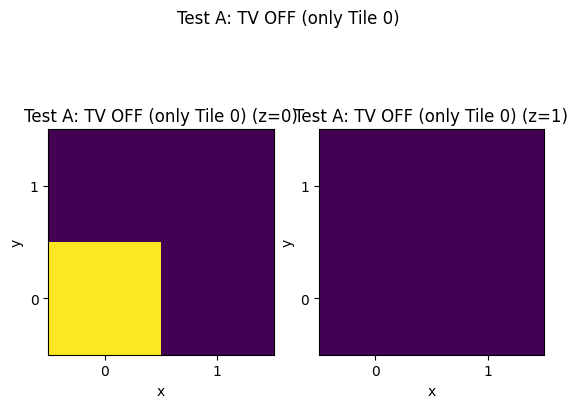

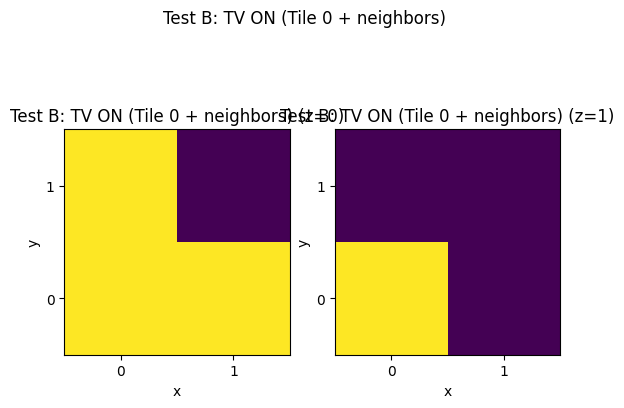

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Nonzero tile sets from your output
nz_A = {0}
nz_B = {0,1,2,4}

def show_tiles(active_set, title):
    # tile id = ix + 2*(iy + 2*iz)
    grid = np.zeros((2,2,2), dtype=int)
    for z in range(2):
        for y in range(2):
            for x in range(2):
                tid = x + 2*(y + 2*z)
                grid[x,y,z] = 1 if tid in active_set else 0

    # show two slices: z=0 and z=1
    fig, axs = plt.subplots(1,2)
    axs[0].imshow(grid[:,:,0].T, origin="lower")
    axs[0].set_title(f"{title} (z=0)")
    axs[0].set_xticks([0,1]); axs[0].set_yticks([0,1])
    axs[0].set_xlabel("x"); axs[0].set_ylabel("y")

    axs[1].imshow(grid[:,:,1].T, origin="lower")
    axs[1].set_title(f"{title} (z=1)")
    axs[1].set_xticks([0,1]); axs[1].set_yticks([0,1])
    axs[1].set_xlabel("x"); axs[1].set_ylabel("y")

    plt.suptitle(title)
    plt.show()

show_tiles(nz_A, "Test A: TV OFF (only Tile 0)")
show_tiles(nz_B, "Test B: TV ON (Tile 0 + neighbors)")


In [4]:
from pathlib import Path

# Resolve repo root reliably (works even if notebook cwd changes)
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "lpbf_to").exists():
    # if you're inside notebooks/, go one level up
    REPO_ROOT = Path.cwd().parent

asset_dir = str(REPO_ROOT / "lpbf_to" / "surrogates" / "meltpool_v1")
print("REPO_ROOT:", REPO_ROOT)
print("asset_dir:", asset_dir)
print("config exists?:", (Path(asset_dir) / "surrogate_config.json").exists())


REPO_ROOT: /workspaces/lpbf_project
asset_dir: /workspaces/lpbf_project/lpbf_to/surrogates/meltpool_v1
config exists?: True


In [5]:
import torch
from lpbf_to.losses.manufacturing_loss import ManufacturingLoss, Bounds

torch.manual_seed(0)

# Fixed setup (matches your validated smoke tests)
tile_shape = (2,2,2)
K = 8
grid_shape = (32,32,16)
tile_A = 0

P_raw = torch.nn.Parameter(torch.zeros(K))
v_raw = torch.nn.Parameter(torch.zeros(K))

rho = torch.rand(*grid_shape)
tile_indices = torch.randint(0, K, grid_shape, dtype=torch.int64)

mfg = ManufacturingLoss(
    asset_dir=asset_dir,
    tile_shape=tile_shape,
    bounds_by_material={"IN718": Bounds(P_min=200, P_max=400, v_min=400, v_max=1100)},
    tv_weight=0.0,
    rho_power=4.0,
)


material = "IN718"
h_mm = 0.10
t_mm = 0.04

def zero_grads(*params):
    for p in params:
        if p.grad is not None:
            p.grad.zero_()

def make_active_mask_for_tile(tile_indices, tile_id):
    return (tile_indices == tile_id).to(dtype=torch.float32)

def neighbor_tiles_2x2x2(tile_id):
    nx, ny, nz = 2, 2, 2
    ix = tile_id % nx
    iy = (tile_id // nx) % ny
    iz = tile_id // (nx * ny)
    def tid(x,y,z): return x + nx*(y + ny*z)
    neigh = []
    for dx,dy,dz in [(1,0,0),(-1,0,0),(0,1,0),(0,-1,0),(0,0,1),(0,0,-1)]:
        x,y,z = ix+dx, iy+dy, iz+dz
        if 0<=x<nx and 0<=y<ny and 0<=z<nz:
            neigh.append(tid(x,y,z))
    return sorted(neigh)

active_mask = make_active_mask_for_tile(tile_indices, tile_A)

# Forced LOF thresholds: d_req above current mean depth
with torch.no_grad():
    out0 = mfg(
        rho=rho, P_raw=P_raw, v_raw=v_raw, tile_indices=tile_indices,
        material=material, h_mm=h_mm, t_mm=t_mm,
        d_req_um=0.0, d_max_um=1e12,
    )
    depth_mean = float(out0["depth_stats"][1].cpu())

d_req_um = depth_mean + 1000.0
d_max_um = depth_mean + 1e12

# -----------------------
# Test A: TV OFF
# -----------------------
mfg.tv_weight = 0.0
zero_grads(P_raw, v_raw)

outA = mfg(
    rho=rho, P_raw=P_raw, v_raw=v_raw, tile_indices=tile_indices,
    material=material, h_mm=h_mm, t_mm=t_mm,
    d_req_um=d_req_um, d_max_um=d_max_um,
    active_mask=active_mask
)
outA["loss_total_mfg"].backward()

gP_A = P_raw.grad.detach().cpu().clone()
gv_A = v_raw.grad.detach().cpu().clone()

# -----------------------
# Create small discontinuity so L1-TV has nonzero subgradients
# -----------------------
with torch.no_grad():
    P_raw.data[tile_A] += 0.1
    v_raw.data[tile_A] -= 0.1

# -----------------------
# Test B: TV ON
# -----------------------
mfg.tv_weight = 1.0
zero_grads(P_raw, v_raw)

outB = mfg(
    rho=rho, P_raw=P_raw, v_raw=v_raw, tile_indices=tile_indices,
    material=material, h_mm=h_mm, t_mm=t_mm,
    d_req_um=d_req_um, d_max_um=d_max_um,
    active_mask=active_mask
)
outB["loss_total_mfg"].backward()

gP_B = P_raw.grad.detach().cpu().clone()
gv_B = v_raw.grad.detach().cpu().clone()

expected_tiles = sorted([tile_A] + neighbor_tiles_2x2x2(tile_A))

print("Depth mean (for thresholds):", depth_mean)
print("Expected tiles (tile_A + neighbors):", expected_tiles)
print("Nonzero tiles A (P):", (gP_A.abs()>1e-12).nonzero().flatten().tolist())
print("Nonzero tiles B (P):", (gP_B.abs()>1e-12).nonzero().flatten().tolist())


Depth mean (for thresholds): 35954.49609375
Expected tiles (tile_A + neighbors): [0, 1, 2, 4]
Nonzero tiles A (P): [0]
Nonzero tiles B (P): [0, 1, 2, 4]


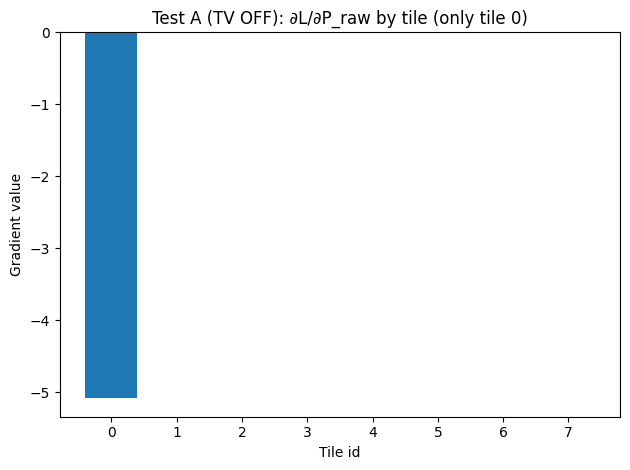

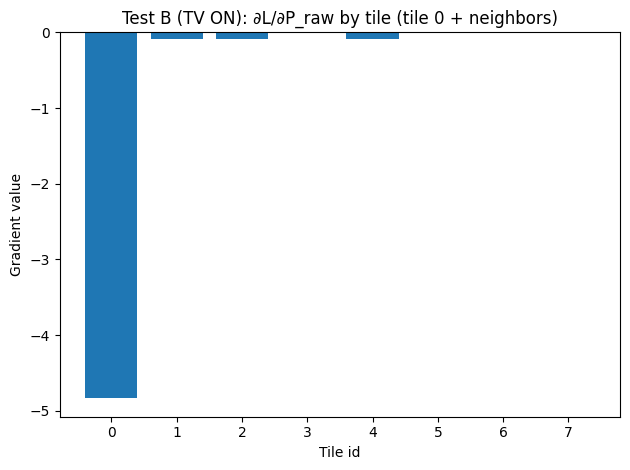

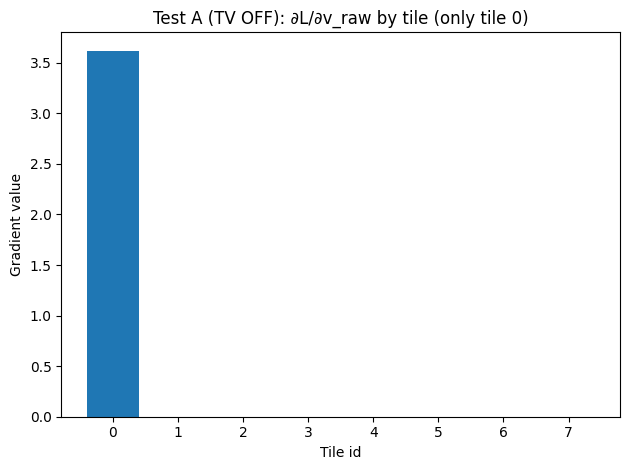

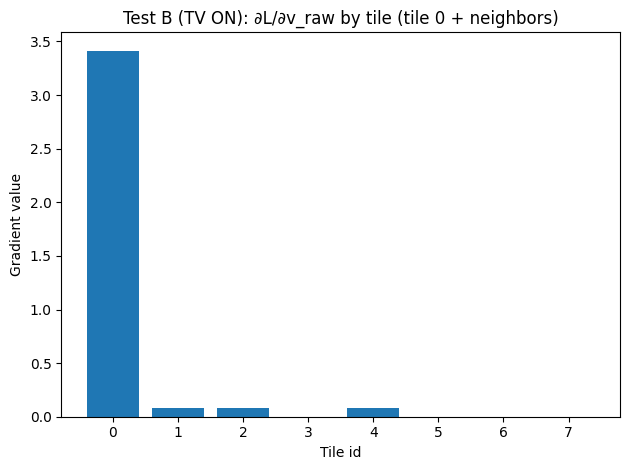

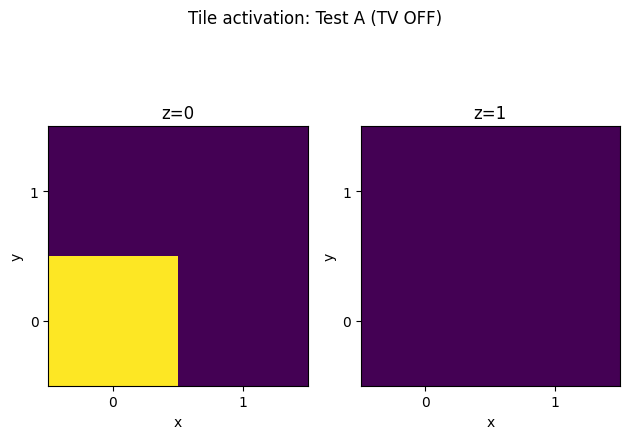

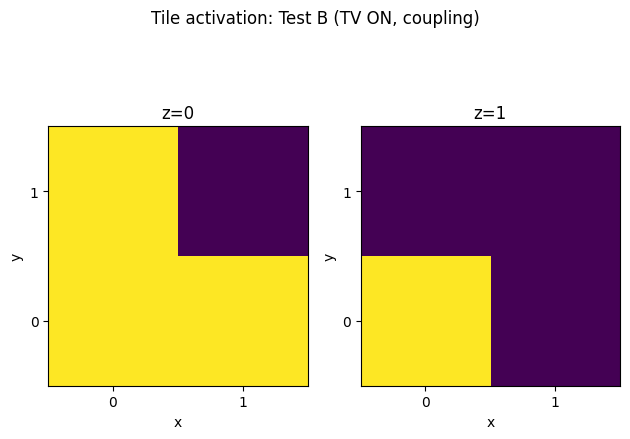

Saved images in outputs/:
 - smoke_testA_grad_P.png
 - smoke_testB_grad_P.png
 - smoke_testA_grad_v.png
 - smoke_testB_grad_v.png
 - tile_activation_testA.png
 - tile_activation_testB.png


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("outputs", exist_ok=True)
tiles = np.arange(8)

def barplot(grads, title, fname):
    plt.figure()
    plt.bar(tiles, grads.numpy())
    plt.xticks(tiles)
    plt.xlabel("Tile id")
    plt.ylabel("Gradient value")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"outputs/{fname}", dpi=200)
    plt.show()

# Bar plots (P_raw)
barplot(gP_A, "Test A (TV OFF): ∂L/∂P_raw by tile (only tile 0)", "smoke_testA_grad_P.png")
barplot(gP_B, "Test B (TV ON): ∂L/∂P_raw by tile (tile 0 + neighbors)", "smoke_testB_grad_P.png")

# Bar plots (v_raw)
barplot(gv_A, "Test A (TV OFF): ∂L/∂v_raw by tile (only tile 0)", "smoke_testA_grad_v.png")
barplot(gv_B, "Test B (TV ON): ∂L/∂v_raw by tile (tile 0 + neighbors)", "smoke_testB_grad_v.png")

# 2x2x2 activation diagram (binary: expected neighbor set)
nz_A = {0}
nz_B = set(expected_tiles)

def show_tiles(active_set, title, fname):
    grid = np.zeros((2,2,2), dtype=int)
    for z in range(2):
        for y in range(2):
            for x in range(2):
                tid = x + 2*(y + 2*z)
                grid[x,y,z] = 1 if tid in active_set else 0

    fig, axs = plt.subplots(1, 2)
    axs[0].imshow(grid[:,:,0].T, origin="lower")
    axs[0].set_title("z=0")
    axs[0].set_xticks([0,1]); axs[0].set_yticks([0,1])
    axs[0].set_xlabel("x"); axs[0].set_ylabel("y")

    axs[1].imshow(grid[:,:,1].T, origin="lower")
    axs[1].set_title("z=1")
    axs[1].set_xticks([0,1]); axs[1].set_yticks([0,1])
    axs[1].set_xlabel("x"); axs[1].set_ylabel("y")

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(f"outputs/{fname}", dpi=200)
    plt.show()

show_tiles(nz_A, "Tile activation: Test A (TV OFF)", "tile_activation_testA.png")
show_tiles(nz_B, "Tile activation: Test B (TV ON, coupling)", "tile_activation_testB.png")

print("Saved images in outputs/:")
print(" - smoke_testA_grad_P.png")
print(" - smoke_testB_grad_P.png")
print(" - smoke_testA_grad_v.png")
print(" - smoke_testB_grad_v.png")
print(" - tile_activation_testA.png")
print(" - tile_activation_testB.png")
